In [10]:
import numpy as np
import matplotlib.pyplot as plt
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import maps, data as simpeg_data
from simpeg import data_misfit, regularization, optimization, inverse_problem, directives, inversion
from simpeg.electromagnetics import resistivity as dc
from simpeg.electromagnetics.static.utils.static_utils import (
    plot_pseudosection,
    apparent_resistivity_from_voltage,
    generate_dcip_sources_line
)
from scipy import sparse as sp
from scipy.spatial import cKDTree

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlepad": 10,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})
%autosave 0

Autosave disabled


### Problem Setup: 2D DC Resistivity

In [2]:
xx = (np.linspace(-1600, 1600, 81))
zz = np.zeros(np.shape(xx))
topo = np.c_[mkvc(xx), mkvc(zz)]


In [3]:
dx, dz = 10, 10
nx, nz = 320, 50
hx = dx * np.ones(nx)
hz = dz * np.ones(nz)
mesh = TensorMesh([hx, hz], origin=[-1600, -nz*dz + 30])

print(f"Mesh: {mesh.nC} cells ({nx} x {nz})")
print(f"Domain: x=[{mesh.nodes_x.min()}, {mesh.nodes_x.max()}], z=[{mesh.nodes_y.min()}, {mesh.nodes_y.max()}]")
active_cells = active_from_xyz(mesh, topo)
print(f"Active cells: {active_cells.sum()} out of {mesh.nC}")
mesh

Mesh: 16000 cells (320 x 50)
Domain: x=[-1600.0, 1600.0], z=[-470.0, 30.0]
Active cells: 15040 out of 16000


TensorMesh: 16,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    320     -1,600.00      1,600.00     10.00     10.00    1.00
   y     50       -470.00         30.00     10.00     10.00    1.00

In [4]:
# True model: two conductive blocks 
sigma_air = np.log(1e-8)         
sigma_background = np.log(1e-3)  
sigma_anomaly    = np.log(1e-1)  

block_x1 = [300, 450]
block_z1 = [-150, -50]

block_x2 = [-450, -200]
block_z2 = [-150, -50]

sigma_true = sigma_background * np.ones(mesh.nC)
sigma_true[~active_cells] = sigma_air

block_inds = (
    (mesh.cell_centers[:, 0] >= block_x1[0]) &
    (mesh.cell_centers[:, 0] <= block_x1[1]) &
    (mesh.cell_centers[:, 1] >= block_z1[0]) &
    (mesh.cell_centers[:, 1] <= block_z1[1])
)

block_inds_2 = (
    (mesh.cell_centers[:, 0] >= block_x2[0]) &
    (mesh.cell_centers[:, 0] <= block_x2[1]) &
    (mesh.cell_centers[:, 1] >= block_z2[0]) &
    (mesh.cell_centers[:, 1] <= block_z2[1])
)

sigma_true[block_inds]   = sigma_anomaly
sigma_true[block_inds_2] = sigma_anomaly

n_block1 = block_inds.sum(); n_block2 = block_inds_2.sum()
print(f"Block 1: {n_block1} cells, Block 2: {n_block2} cells")

Block 1: 150 cells, Block 2: 250 cells


### Survey Setup

In [5]:
survey_type = "dipole-dipole"
data_type = "volt"
dimension_type = "2D"
end_locations_list = np.r_[-1000.0, 1000.0]
station_spacing = 30.0
num_rx_per_src = 30

source_list = generate_dcip_sources_line(
    survey_type, data_type, dimension_type,
    end_locations_list, topo, num_rx_per_src, station_spacing,
)
survey = dc.survey.Survey(source_list)
print(f"Number of data: {survey.nD}")

Number of data: 1485


In [12]:
active_map = maps.InjectActiveCells(mesh, active_cells, np.log(1e-8))
sim_map = maps.ExpMap(mesh) * active_map
survey.drape_electrodes_on_topography(mesh, active_cells=active_cells, option="center")
simulation = dc.Simulation2DNodal(    mesh, survey=survey, sigmaMap=sim_map)

data_true = simulation.dpred(sigma_true[active_cells])

# Add noise: relative + absolute floor
relative_error = 0.02
noise_floor = 0.0002 *np.max(np.abs(data_true))
dclean = data_true
std = np.sqrt((relative_error * np.abs(dclean)) ** 2 + noise_floor**2)
noise = std * np.random.randn(len(dclean))
dobs = dclean + noise

print(f"Data range: [{dobs.min():.2e}, {dobs.max():.2e}]")
print(f"noise_std range: [{std.min():.2e}, {std.max():.2e}]")
print("Noise Floor: {:.2e}".format(noise_floor))

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


Data range: [-1.88e+00, 9.27e-04]
noise_std range: [3.65e-04, 3.65e-02]
Noise Floor: 3.65e-04


### RBF Level Set Setup

In [13]:
def _sigma(alpha_raw):
    """Bounded shape coefficients"""
    return np.arctan(alpha_raw * 0.5)

def _sigma_prime(alpha_raw):
    """Derivative of bounded shape coefficients"""
    return 2.0 / (4.0 + alpha_raw ** 2)

# ------------------------------------------------------------------ #
def rbf_kernel(params, xyz, m, use_normalised_C=False, return_deriv=False):
    """
    RBF level-set kernel using sparse Gaussian RBF matrix.

    Parameters
    ----------
    params : list  [centres (N,d), eps, w_1, ..., w_N]
    xyz    : (n_active, d) array -- mesh cell centres (active only)
    m      : (N+2,) array -- [alpha_0, ..., alpha_{N-1}, c_low, c_high]
    use_normalised_C : bool -- normalise psi columns to unit L2 norm
    return_deriv : bool -- return (n_active, N+2) Jacobian if True
    """
    centres = np.asarray(params[0], dtype=np.float64)
    N       = centres.shape[0]
    eps     = float(params[1])
    rbf_w   = np.asarray(params[2:2+N], dtype=np.float64)
    xyz     = np.asarray(xyz, dtype=np.float64)

    c_low  = float(m[N])
    c_high = float(m[N + 1])

    # ---- sparse Gaussian RBF matrix  psi(x) ----------------------------
    threshold      = 1e-12
    support_radius = rbf_w.max() * np.sqrt(-np.log(threshold))

    tree_xyz = cKDTree(xyz)
    tree_cen = cKDTree(centres)
    dist_coo = tree_xyz.sparse_distance_matrix(
        tree_cen, max_distance=support_radius, output_type="coo_matrix")

    w2 = (2*rbf_w[dist_coo.col]) ** 2
    psi_data = np.exp(-(dist_coo.data ** 2) / w2)

    keep = psi_data > threshold
    psi  = sp.csr_matrix(
        (psi_data[keep], (dist_coo.row[keep], dist_coo.col[keep])),
        shape=(xyz.shape[0], N))

    # column normalisation: each RBF column scaled to unit L2 norm
    # Ensures alpha coefficients are on a comparable scale across RBFs.
    if use_normalised_C:
        col_norms = np.asarray(psi.power(2).sum(axis=0)).flatten() ** 0.5
        col_norms = np.where(col_norms > 0, col_norms, 1.0)
        psi = psi @ sp.diags(1.0 / col_norms)

    # ---- level-set and Heaviside ---------------------------------
    alpha = _sigma(m[:N])           # bounded coefficients
    phi   = psi @ alpha             # level-set field
    arg   = (np.pi / eps) * phi
    H     = 0.5 + (1.0 / np.pi) * np.arctan(arg)

    # ---- physical property model ---------------------------------------
    f = c_low + (c_high - c_low) * H

    if not return_deriv:
        return f

    # Jacobian columns 0..N-1: df/d(alpha_j)
    H_prime     = 1.0 / (eps * (1.0 + arg ** 2))
    sigma_prime = _sigma_prime(m[:N])
    scale_row   = (c_high - c_low) * H_prime
    J_alpha = sp.diags(scale_row) @ psi @ sp.diags(sigma_prime)  # (n_pts, N)

    # Jacobian column N: df/d(c_low) = 1 - H  (dense column)
    J_clow  = (1.0 - H).reshape(-1, 1)

    # Jacobian column N+1: df/d(c_high) = H  (dense column)
    J_chigh = H.reshape(-1, 1)

    # Concatenate: result is (n_pts, N+2)
    J = sp.hstack([J_alpha, sp.csr_matrix(J_clow), sp.csr_matrix(J_chigh)], format="csr")
    return J


In [23]:
def make_grid(xmin, xmax, zmin, zmax, spacing):
    x = np.arange(xmin, xmax + 0.5 * spacing, spacing)
    z = np.arange(zmin, zmax + 0.5 * spacing, spacing)
    xx, zz = np.meshgrid(x, z)
    return np.c_[xx.ravel(), zz.ravel()]

def core_noncore_centres(
    x_min, x_max, z_min, z_max,
    x_core_min, x_core_max, z_core_min, z_core_max,
    core_spacing, noncore_spacing,
):
    core = make_grid(x_core_min, x_core_max, z_core_min, z_core_max, core_spacing)
    coarse_all = make_grid(x_min, x_max, z_min, z_max, noncore_spacing)
    coarse_in_core = (
        (coarse_all[:, 0] >= x_core_min) & (coarse_all[:, 0] <= x_core_max) &
        (coarse_all[:, 1] >= z_core_min) & (coarse_all[:, 1] <= z_core_max)
    )
    noncore = coarse_all[~coarse_in_core]
    centres = np.vstack([core, noncore])
    core_idx = np.arange(core.shape[0])
    noncore_idx = np.arange(core.shape[0], centres.shape[0])
    return centres, core_idx, noncore_idx

x_min, x_max   = -1600.0, 1600.0
z_min, z_max   = -400.0,     0.0

x_core_min, x_core_max = -800.0, 800.0
z_core_min, z_core_max = -250.0, -20.0

core_spacing    = 60.0
noncore_spacing = core_spacing * 5

rbf_centers, core_idx, noncore_idx = core_noncore_centres(
    x_min, x_max, z_min, z_max,
    x_core_min, x_core_max, z_core_min, z_core_max,
    core_spacing, noncore_spacing,
)
N = rbf_centers.shape[0]
rbf_w = np.empty(N)
rbf_w[core_idx]    = 0.35 * core_spacing
rbf_w[noncore_idx] = 0.4 * noncore_spacing

alpha_init = np.full(N, -1.0)
alpha_init[noncore_idx] = -1.0
# initial alpha activation
x1, z1 = 350, -100
anom_idx = np.where(np.sqrt((rbf_centers[:, 0] - x1)**2 +
                             (rbf_centers[:, 1] - z1)**2) <= core_spacing)[0]
alpha_init[anom_idx] = 1.0
clow, chigh = np.log(1e-4), np.log(1e1)

eps_init    = 0.1
extra_params = [rbf_centers, eps_init] + list(rbf_w)

params  = np.r_[alpha_init, clow, chigh]
n_params = params.size

print(f"RBF centres: {N} ({len(core_idx)} core, {len(noncore_idx)} noncore)")
print(f"Total params: {n_params}  ({N} alpha + 2 limits)")
print(f"Core spacing: {core_spacing:.0f} m  width={0.3*core_spacing:.1f} m")

param_map = maps.ParametricRBFMapping(
    mesh=mesh, nP=n_params, active_cells=active_cells,
    forward_transform=rbf_kernel, params=extra_params,
)
sigma_init = maps.ExpMap()*active_map*param_map*(params)

RBF centres: 158 (140 core, 18 noncore)
Total params: 160  (158 alpha + 2 limits)
Core spacing: 60 m  width=18.0 m


### Least Squares Inversion

In [33]:
dmisfit_l2 = data_misfit.L2DataMisfit(
    data=simpeg_data.Data(survey, dobs=dobs, relative_error=relative_error, noise_floor=noise_floor),
    simulation=simulation
)

reg_l2 = regularization.WeightedLeastSquares(mesh=mesh, active_cells=active_cells)

# Bounds in log-conductivity space
lower_l2 = np.log(5e-4) * np.ones(active_cells.sum())
upper_l2 = np.log(5e-0)  * np.ones(active_cells.sum())
opt_l2 = optimization.ProjectedGNCG(
    maxIter=30, maxIterLS=20, maxIterCG=30,
    lower=lower_l2, upper=upper_l2)

inv_prob_l2 = inverse_problem.BaseInvProblem(dmisfit_l2, reg_l2, opt_l2)
save_l2 = directives.SaveOutputEveryIteration(save_txt=False)
beta_est_l2   = directives.BetaEstimate_ByEig(beta0_ratio=1e1, n_pw_iter=1)
target_l2     = directives.TargetMisfit(chifact=1.0)
beta_sched_l2 = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)  # halve every iter
inv_l2 = inversion.BaseInversion(
    inv_prob_l2, directiveList=[beta_est_l2, beta_sched_l2, target_l2, save_l2, ])
print("L2 inversion set up.")

L2 inversion set up.


In [16]:
m0_l2    = sigma_background * np.ones(active_cells.sum())  # start at background
m_opt_l2 = inv_l2.run(m0_l2)
sigma_l2 = sim_map * m_opt_l2
np.save("results/dcr_two_blocks_l2.npy", sigma_l2)
print("L2 inversion complete.")

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 1485.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  2.61e+01  3.49e+05  0.00e+00  3.49e+05                         0           inf          inf                
   1  2.61e+01  2.18e+05  2.15e+03  2.74e+05    4.15e+02      0      11       1.77e-08     6.74e-04              
   2  1.31e+01  1.75e+05  4.68e+03  2.36e+05    3.76e+02      0      11       5.96e-08     5.95e-04   Skip BFGS  
   3  6.53e+00  1.31e+05  9.79e+03  1.95e+05    3.73e+02      0      14       4.27e-08     3.55e-04   Skip BFGS  
   4  3.27e+00  9.43e+04  1.83e+04  1.54e+05    3.56e+02      0      16       1.36e-07     7.96e-04   Skip BFGS  
   5  1.63e+00  6.46e+04  3.17e+04  1.16e+05    3.32e+02      0      20       2.34e-07 

## Level Set Inversion

In [26]:
lower_rbf = np.r_[-5.0 * np.ones_like(alpha_init), np.log(1e-4), np.log(5e-2)]
upper_rbf =  np.r_[5.0 * np.ones_like(alpha_init), np.log(1e-2), np.log(2e1)]
lower_rbf[noncore_idx] = -5.0
upper_rbf[noncore_idx] = -4.99
simulation_param = dc.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=sim_map * param_map)

dmisfit_rbf = data_misfit.L2DataMisfit(
    data=simpeg_data.Data(survey, dobs=dobs, relative_error=relative_error, noise_floor=noise_floor),
    simulation=simulation_param
)
reg_rbf = regularization.WeightedLeastSquares(
    mesh=TensorMesh([np.ones(n_params)]),)

opt_rbf = optimization.ProjectedGNCG(
    maxIter=50, maxIterLS=20, maxIterCG=30,
    lower=lower_rbf, upper=upper_rbf)

inv_prob_rbf = inverse_problem.BaseInvProblem(
    dmisfit_rbf, reg_rbf, opt_rbf, beta=0)

target_rbf   = directives.TargetMisfit(chifact=1.0)
beta_sched = directives.BetaSchedule(coolingFactor=2.0, coolingRate=2)
beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1e0)
save_rbf = directives.SaveOutputEveryIteration(save_txt=False)
inv_rbf = inversion.BaseInversion(
    inv_prob_rbf,
    directiveList=[target_rbf, save_rbf])
np.save("results/dcr_two_blocks_rbf.npy", rbf_centers)

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


In [27]:
m_opt_rbf = inv_rbf.run(params.copy())
sigma_rbf = sim_map * param_map * m_opt_rbf
print("RBF inversion complete.") 

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 1485.0



Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  0.00e+00  8.71e+07  4.69e+02  8.71e+07                         0           inf          inf                
   1  0.00e+00  4.39e+05  5.01e+02  4.39e+05    6.59e+01      0      30       8.38e-01     4.10e+06              
   2  0.00e+00  2.96e+05  5.23e+02  2.96e+05    5.88e+01      0      30       6.15e-03     4.56e+03   Skip BFGS  
   3  0.00e+00  2.45e+05  5.23e+02  2.45e+05    4.34e+01      1      30       8.98e-02     1.42e+04              
   4  0.00e+00  1.65e+05  5.00e+02  1.65e+05    4.50e+01      0      30       2.14e-02     5.81e+03              
   5  0.00e+00  9.16e+04  5.18e+02  9.16e+04    

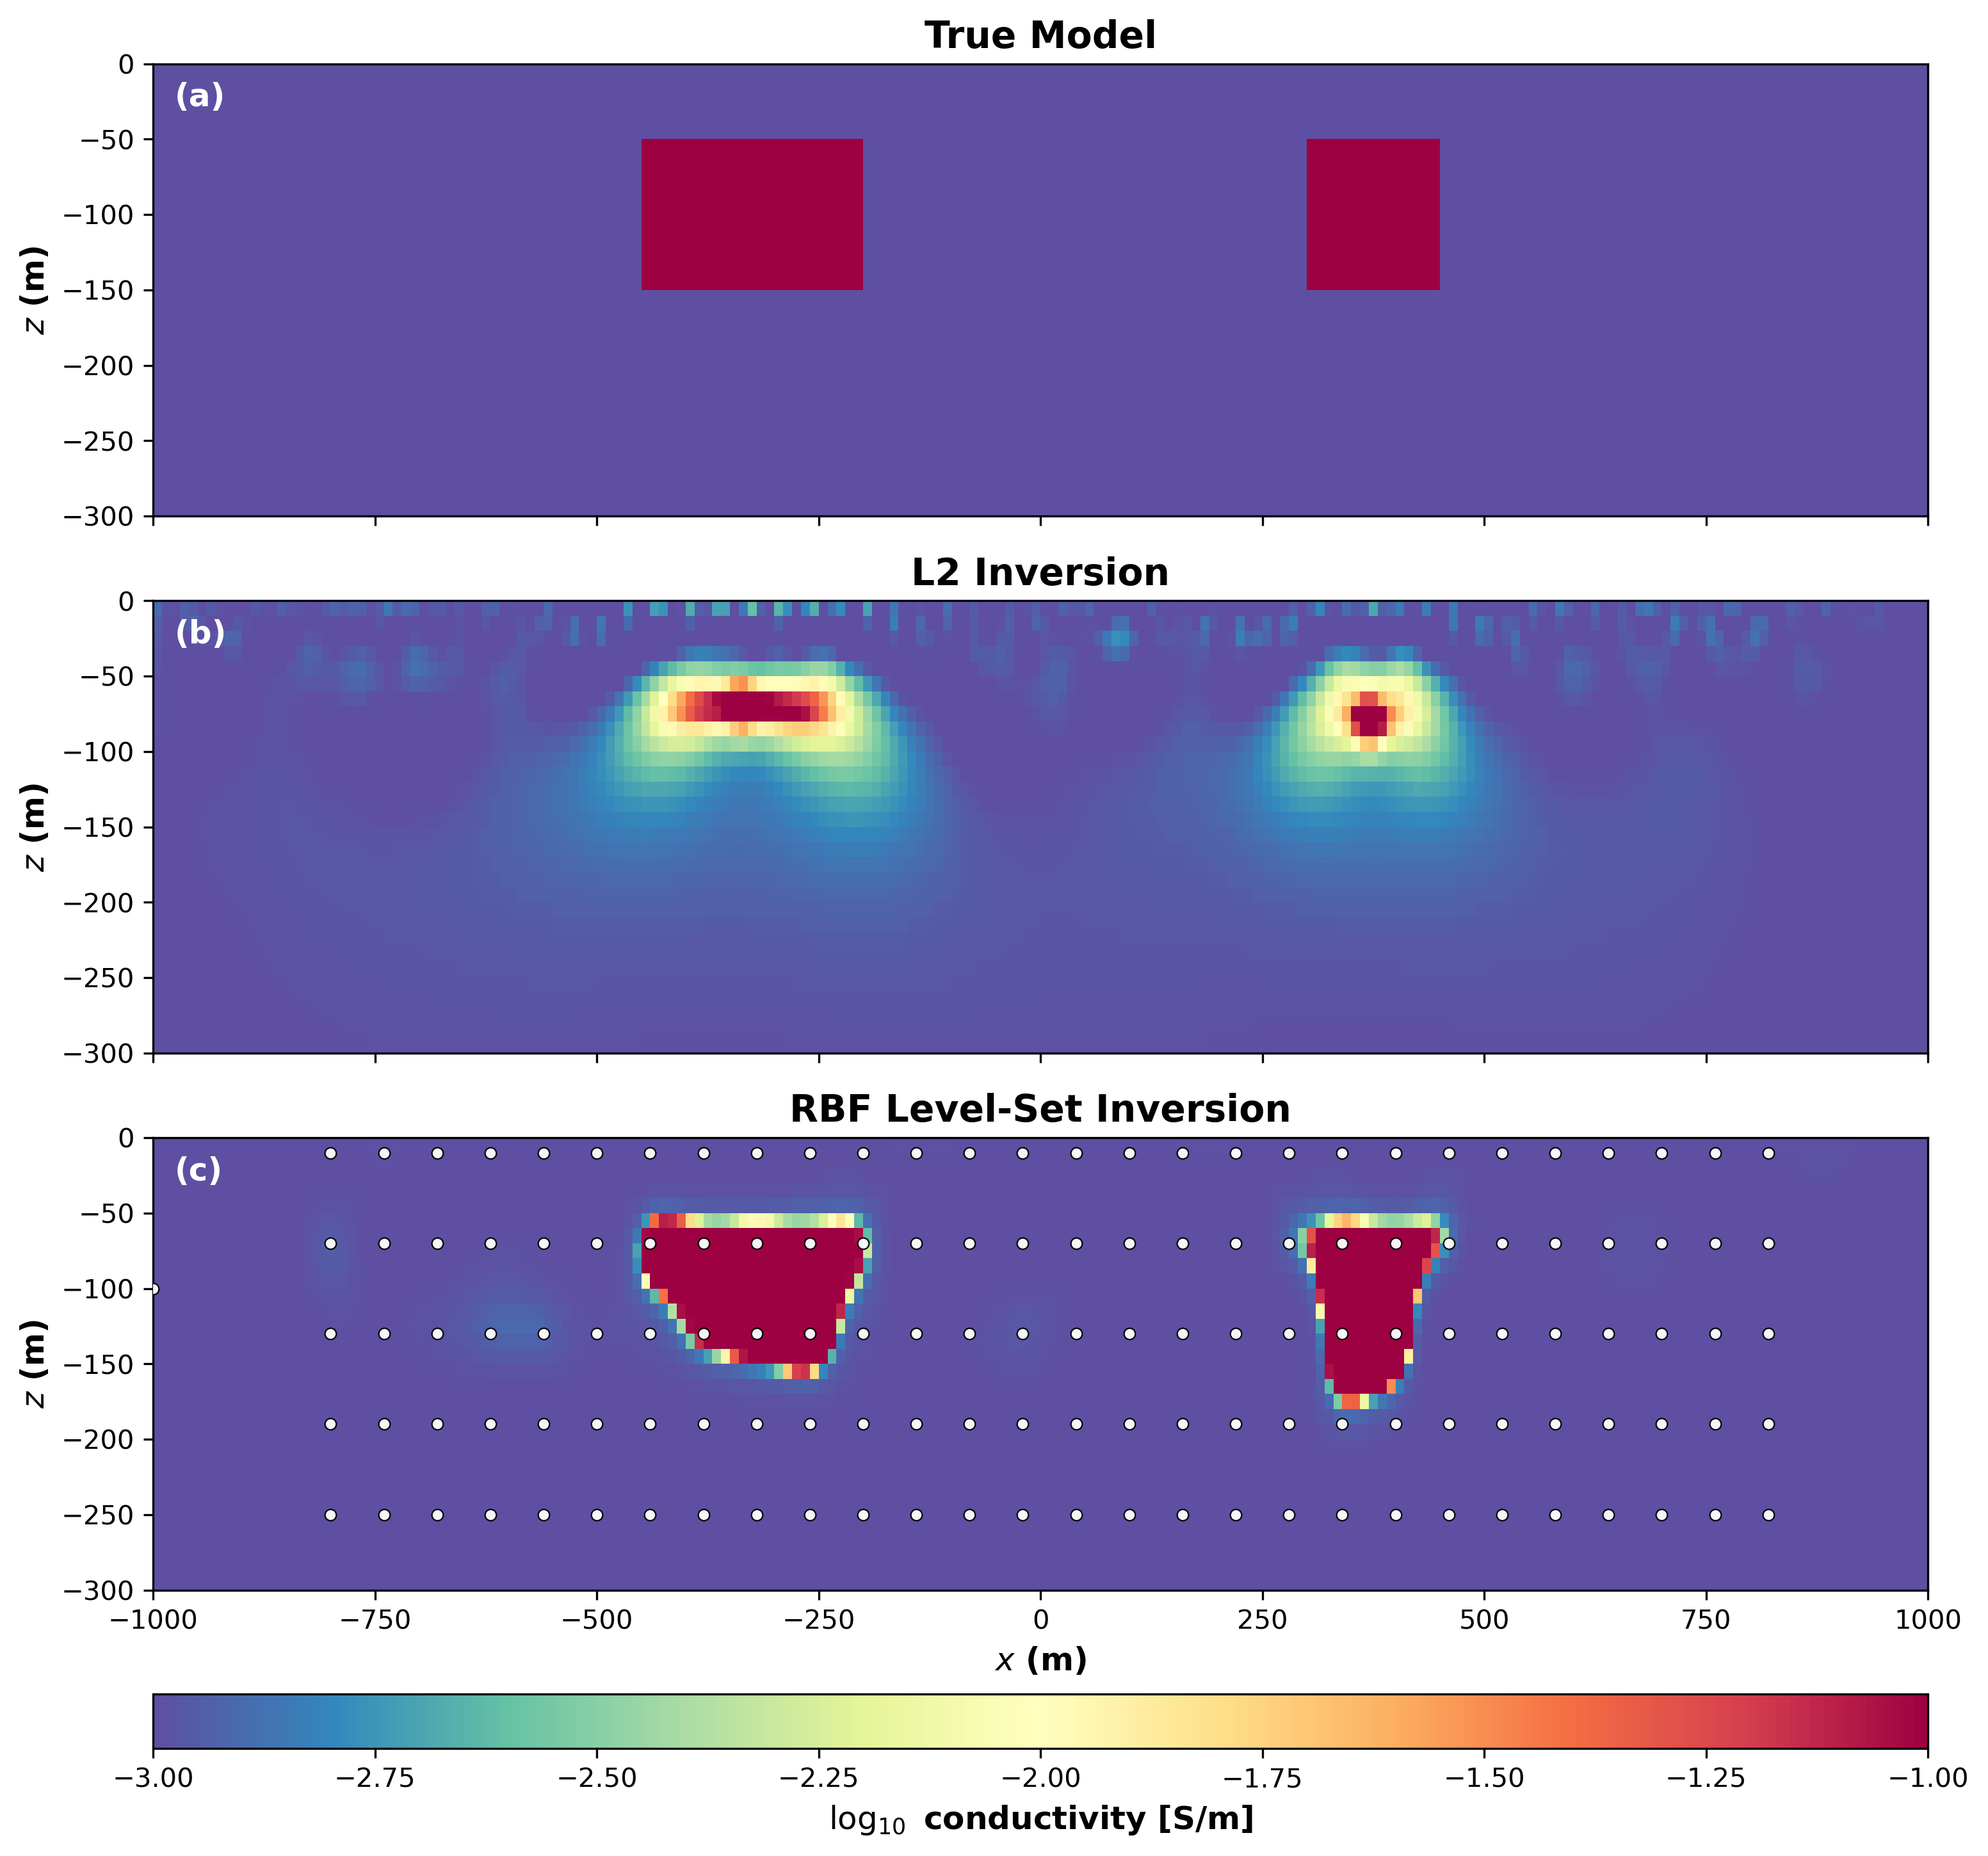

In [29]:
clim = (-3, -1)
n_panels = 3

fig_h = 10.2
fig = plt.figure(figsize=(10.5, fig_h), dpi=300)
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(
    nrows=n_panels + 1,
    ncols=1,
    height_ratios=([1.0] * n_panels) + [0.12],
    hspace=0.24,
    left=0.10,
    right=0.98,
    top=0.96,
    bottom=0.11,
    )

axes = [fig.add_subplot(gs[0, 0])]
for i in range(1, n_panels):
    axes.append(fig.add_subplot(gs[i, 0], sharex=axes[0]))

panel_data = [
    (np.log10(np.exp(sigma_true)), "True Model"),
    (np.log10(sigma_l2), "L2 Inversion"),
    (np.log10(sigma_rbf), "RBF Level-Set Inversion"),
]

panel_labels = ["(a)", "(b)", "(c)"]

mappable = None
for i, (ax, (img_data, title)) in enumerate(zip(axes, panel_data)):
    out = mesh.plot_image(
        img_data,
        ax=ax,
        grid=False,
        clim=clim,
    )
    mappable = out[0]
    out[0].set_cmap("Spectral_r")
    ax.set_aspect("auto")
    ax.set_xlim(-1000, 1000)
    ax.set_ylim(-300, 0)
    ax.set_ylabel(r"$z$ (m)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="semibold", pad=6)
    ax.tick_params(axis="both", which="major", labelsize=10)

    ax.text(
        0.012,
        0.96,
        panel_labels[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        color="white",
        zorder=12,
    )

    if title == "RBF Level-Set Inversion":
        ax.scatter(
            rbf_centers[:, 0],
            rbf_centers[:, 1],
            s=18,
            facecolors="white",
            edgecolors="black",
            linewidths=0.55,
            alpha=0.95,
            zorder=10,
        )

    if i < n_panels - 1:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel(r"$x$ (m)", fontsize=12)

cbar_ax = fig.add_subplot(gs[n_panels, 0])
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"$\log_{10}$ conductivity [S/m]", fontsize=12)
cbar_ax.tick_params(labelsize=10)

cb_pos = cbar_ax.get_position()
cbar_ax.set_position([cb_pos.x0, cb_pos.y0 - 0.010, cb_pos.width, cb_pos.height])

plt.show()

In [30]:
dpred_l2   = simulation.dpred(m_opt_l2)
dpred_rbf  = simulation_param.dpred(m_opt_rbf)

app_l2   = 1.0 / apparent_resistivity_from_voltage(survey, dpred_l2)
app_rbf  = 1.0 / apparent_resistivity_from_voltage(survey, dpred_rbf)

std_per_datum = np.sqrt((relative_error * np.abs(dobs))**2 + noise_floor**2)
resid_l2  = (dobs - dpred_l2)  / std_per_datum
resid_rbf = (dobs - dpred_rbf) / std_per_datum

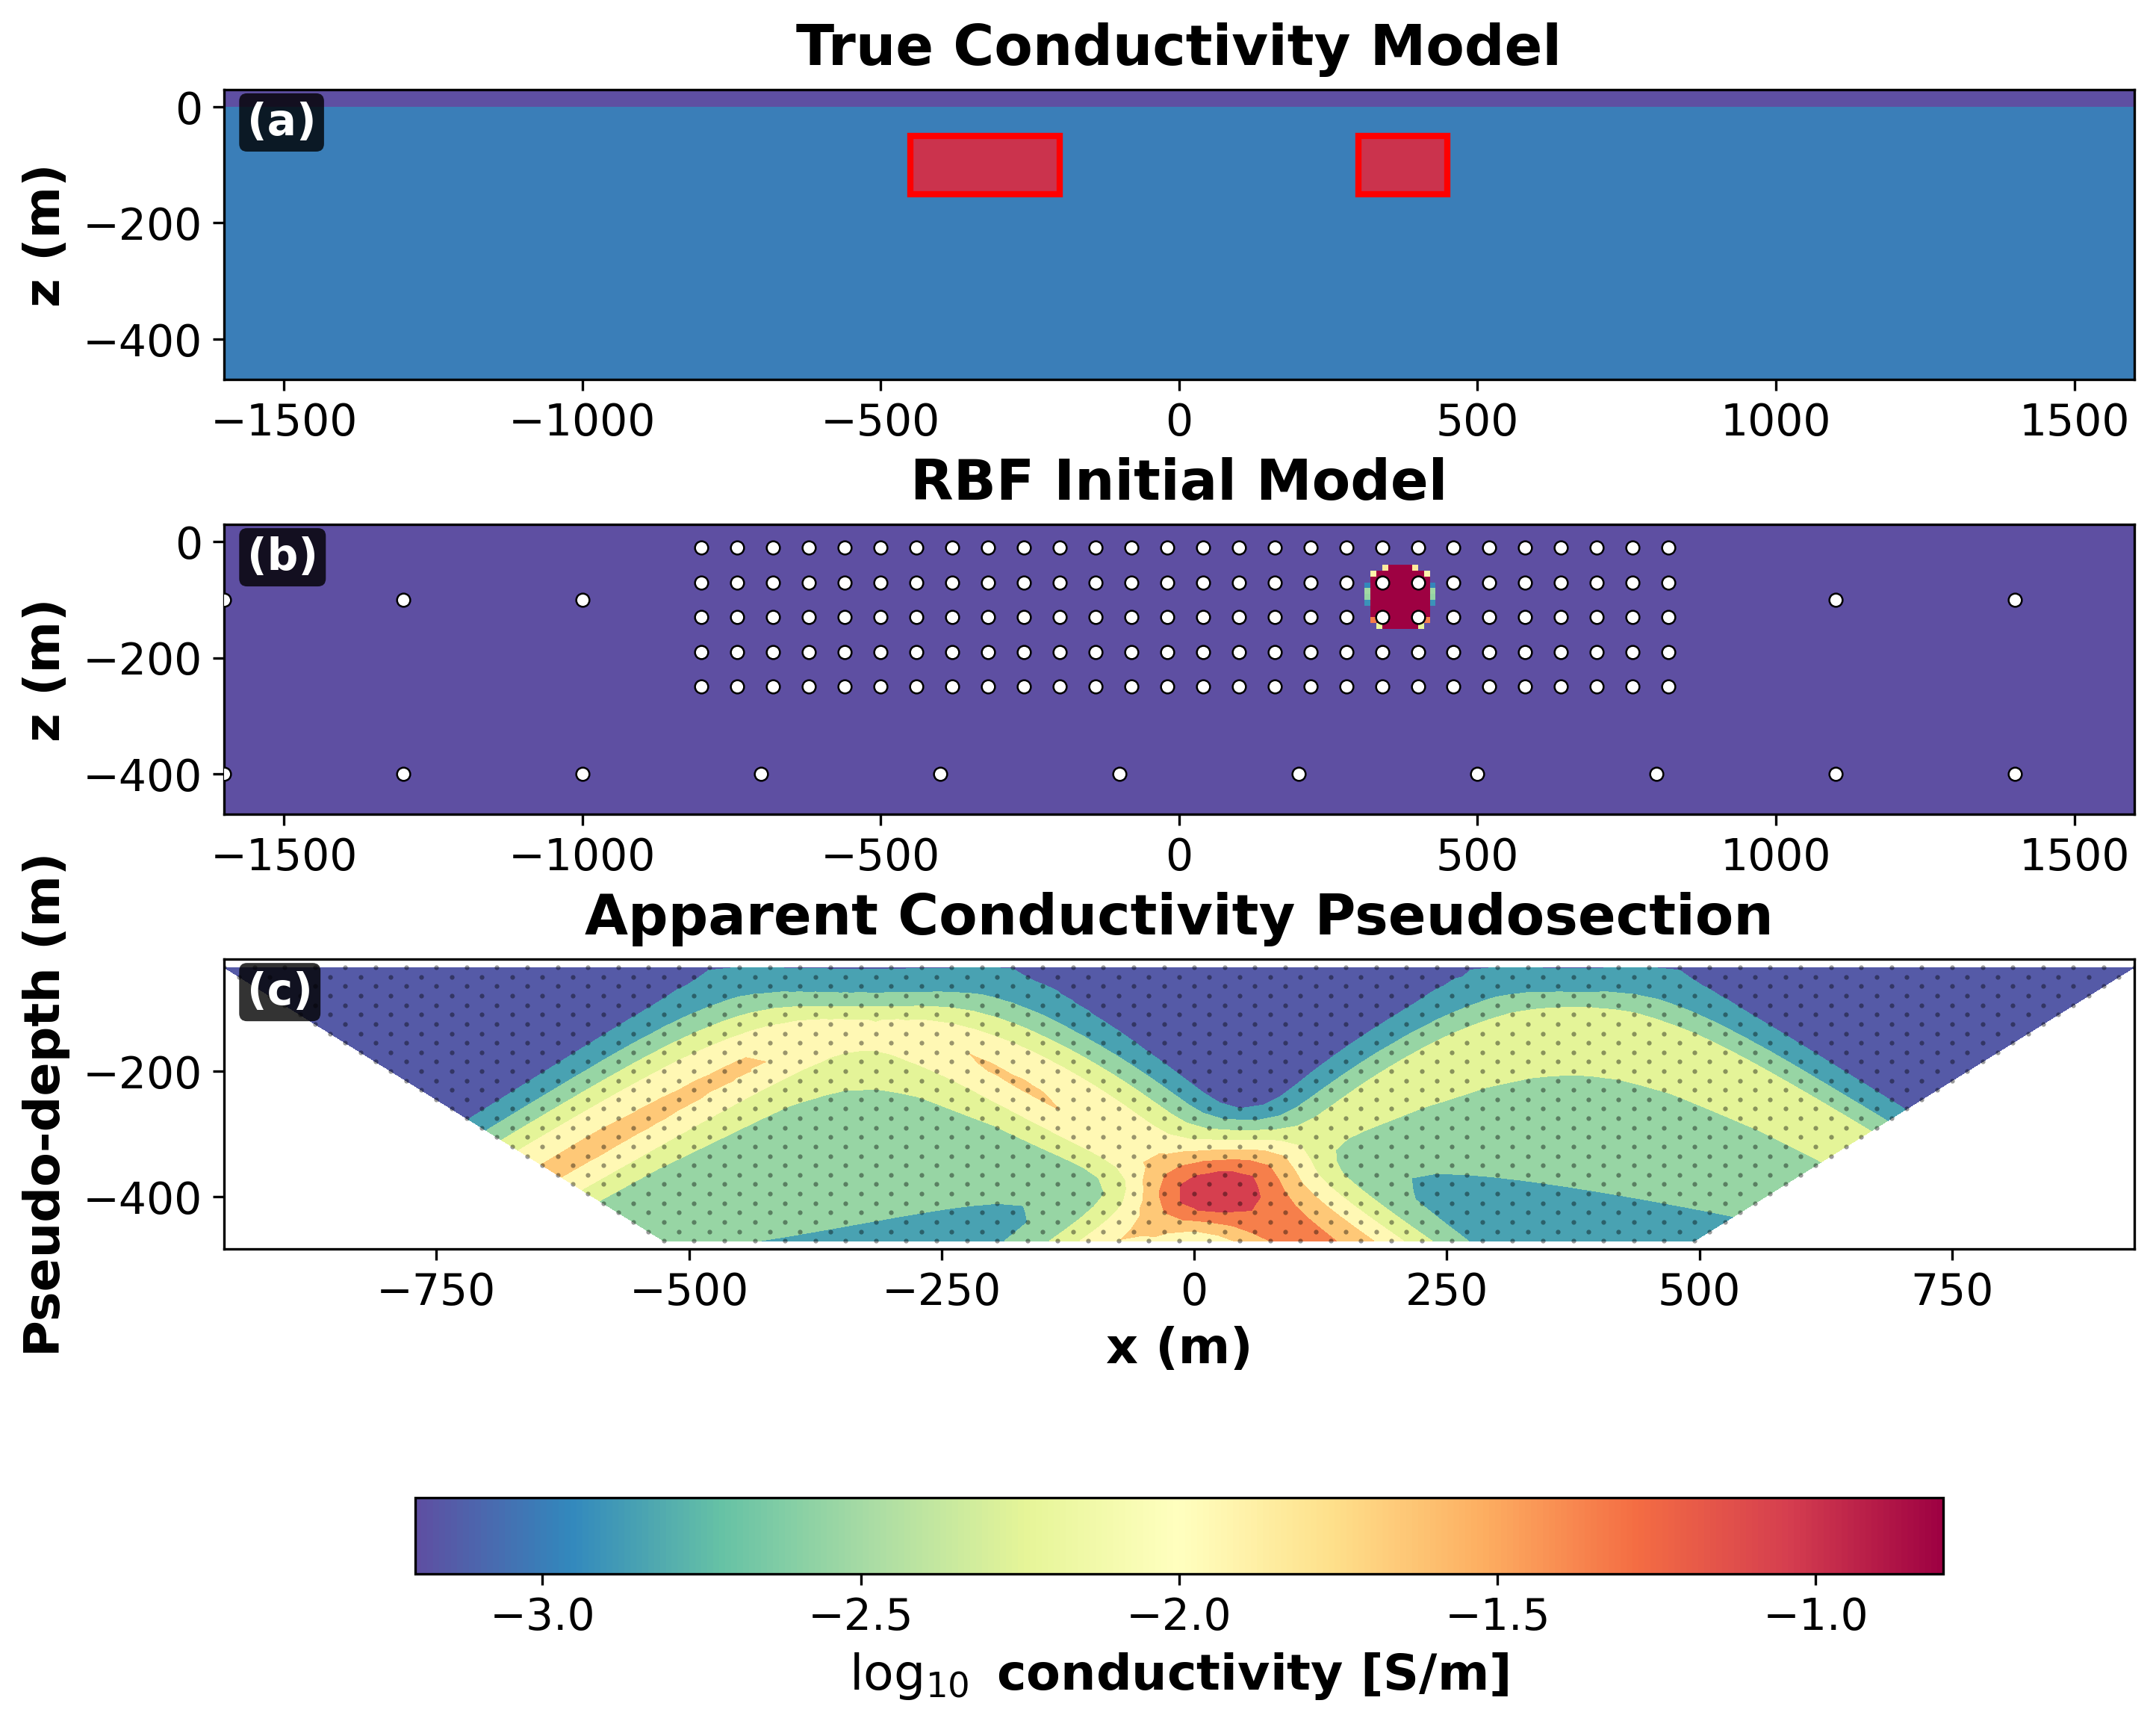

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(11, 9.6), dpi=300,
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.5},
)

def plot_true_boundary(ax):
    rect1 = plt.Rectangle(
        (block_x1[0], block_z1[0]),
        block_x1[1] - block_x1[0],
        block_z1[1] - block_z1[0],
        edgecolor="red", facecolor="none", linewidth=2,
    )
    rect2 = plt.Rectangle(
        (block_x2[0], block_z2[0]),
        block_x2[1] - block_x2[0],
        block_z2[1] - block_z2[0],
        edgecolor="red", facecolor="none", linewidth=2,
    )
    ax.add_patch(rect1)
    ax.add_patch(rect2)

true_log10 = np.log10(np.exp(sigma_true))
out_true = mesh.plot_image(true_log10, ax=ax1, clim=(-3.2, -0.8))
out_true[0].set_cmap("Spectral_r")
plot_true_boundary(ax1)
ax1.set_ylabel("z (m)")
ax1.set_xlabel("")
ax1.set_title("True Conductivity Model", fontsize=18, fontweight="semibold", pad=8)
ax1.tick_params(axis="x", labelbottom=True)
ax1.text(0.012, 0.96, "(a)", transform=ax1.transAxes, ha="left", va="top",
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                   edgecolor="none", alpha=0.8))

rbf_init_log10 = np.log10(np.clip(sigma_init, 1e-12, None))
out_init = mesh.plot_image(rbf_init_log10, ax=ax2, clim=(-3.2, -0.8))
out_init[0].set_cmap("Spectral_r")
ax2.scatter(
    rbf_centers[:, 0], rbf_centers[:, 1],
    s=18, facecolors="white", edgecolors="black", linewidths=0.6, zorder=10
)
ax2.set_title("RBF Initial Model", fontsize=18, fontweight="semibold", pad=8)

ax2.set_ylabel("z (m)")
ax2.set_xlabel("")
ax2.tick_params(axis="x", labelbottom=True)
ax2.text(0.012, 0.96, "(b)", transform=ax2.transAxes, ha="left", va="top",
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                   edgecolor="none", alpha=0.8))

app_cond = 1.0 / apparent_resistivity_from_voltage(survey, dclean)
plot_pseudosection(
    survey,
    dobs=np.log10(np.clip(app_cond, 1e-12, None)),
    plot_type="contourf", ax=ax3, scale="linear",
    clim=(-3.2, -0.8), create_colorbar=False,
    contourf_opts={"cmap": "Spectral_r"},
    data_locations=True,
    mask_topography=False,
)
ax3.set_xlabel("x (m)")
ax3.set_ylabel("Pseudo-depth (m)")
ax3.set_title("Apparent Conductivity Pseudosection", fontsize=18, fontweight="semibold", pad=8)
ax3.text(0.012, 0.96, "(c)", transform=ax3.transAxes, ha="left", va="top",
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                   edgecolor="none", alpha=0.8))

cbar = fig.colorbar(
    out_true[0], ax=[ax1, ax2, ax3], label=r"$\log_{10}$ conductivity [S/m]",
    orientation="horizontal", shrink=0.8
)
cbar.ax.tick_params(labelsize=14)
plt.show()


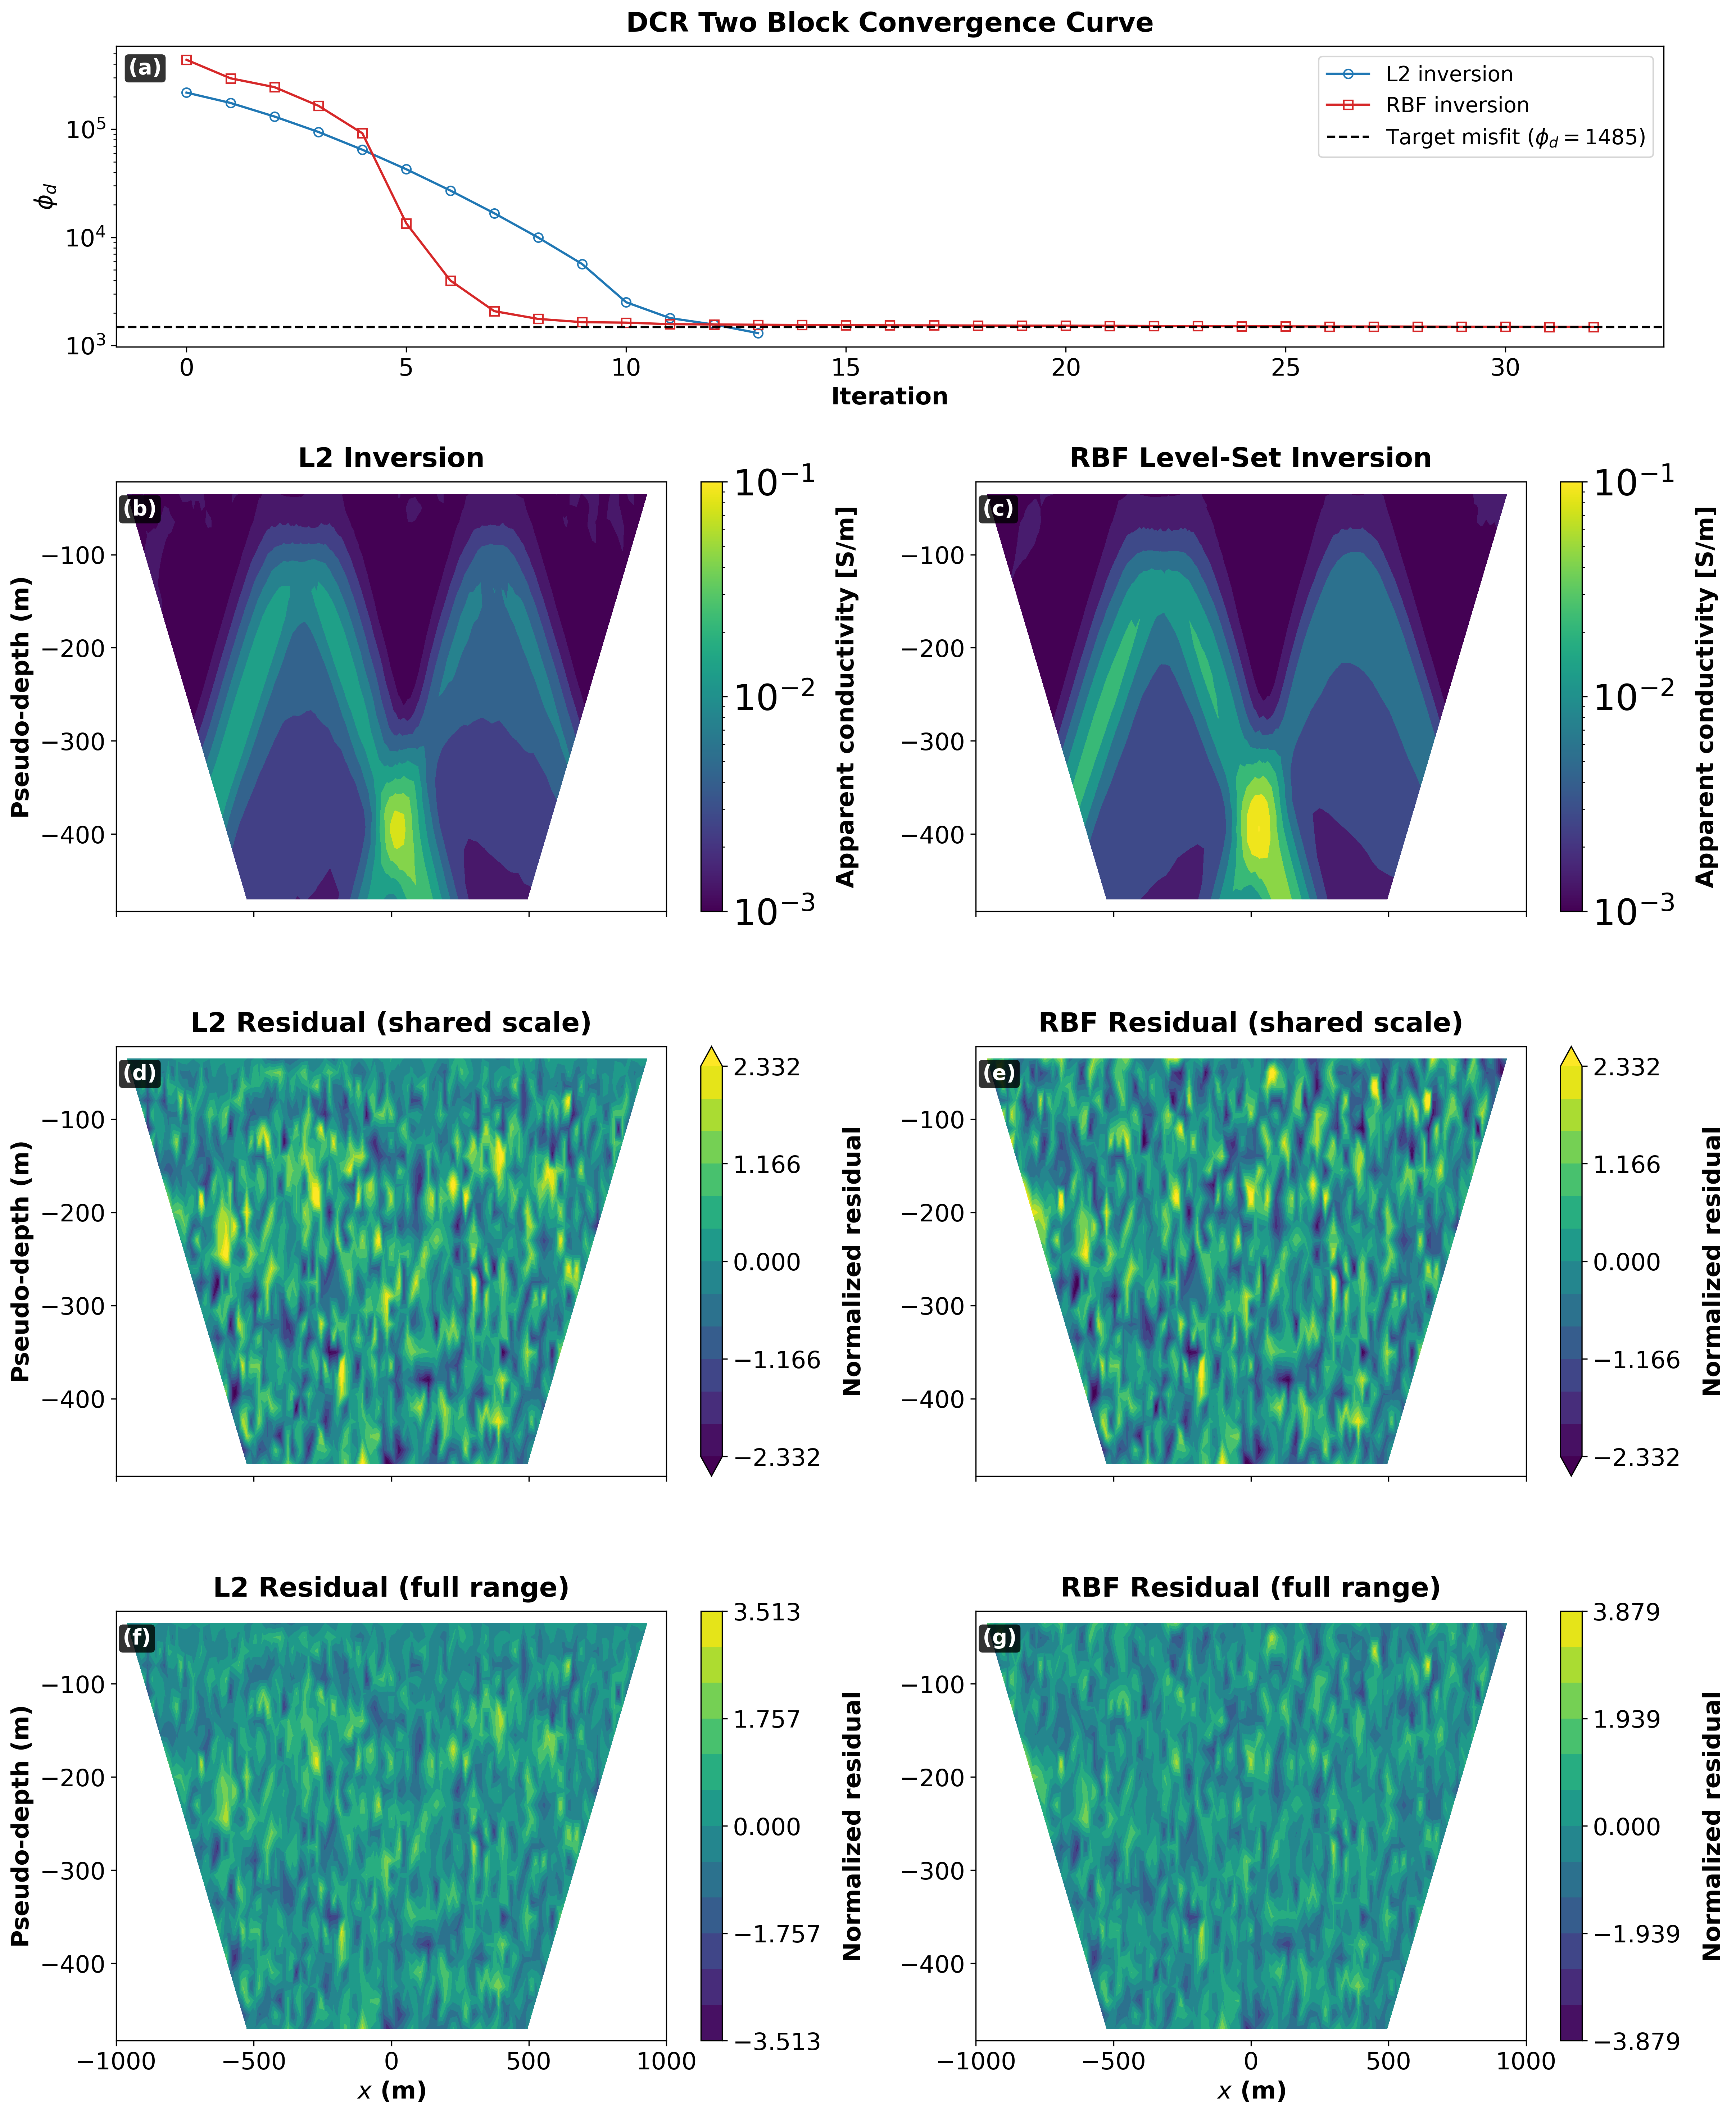

In [35]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

#phid_l2  = np.asarray(save_l2.phi_d)
# save_l2 was recreated after the run mistakenly; phi_d transcribed from the L2 iteration log
phid_l2 = np.array([
    2.18e+05, 1.75e+05, 1.31e+05, 9.43e+04, 6.46e+04,
    4.26e+04, 2.71e+04, 1.67e+04, 9.95e+03, 5.66e+03,
    2.51e+03, 1.79e+03, 1.56e+03, 1.30e+03,
])

phid_rbf = np.asarray(save_rbf.phi_d)
target_misfit = target_l2.target

cond_clim  = (1e-3, 1e-1)
shared_lim = max(np.nanpercentile(np.abs(np.r_[resid_l2, resid_rbf]), 98), 1.0)
lim_l2  = np.nanmax(np.abs(resid_l2))
lim_rbf = np.nanmax(np.abs(resid_rbf))

fig = plt.figure(figsize=(18.5, 24.0), dpi=300)
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(
    nrows=4, ncols=2,
    height_ratios=[0.7, 1.0, 1.0, 1.0],
    hspace=0.34, wspace=0.25,
)

ax_conv   = fig.add_subplot(gs[0, :])
ax_l2     = fig.add_subplot(gs[1, 0])
ax_rbf    = fig.add_subplot(gs[1, 1])
ax_l2_s   = fig.add_subplot(gs[2, 0])
ax_rbf_s  = fig.add_subplot(gs[2, 1])
ax_l2_f   = fig.add_subplot(gs[3, 0])
ax_rbf_f  = fig.add_subplot(gs[3, 1])

ax_conv.semilogy(range(len(phid_l2)),  phid_l2,  "-o", color="tab:blue",
                 markerfacecolor="none", label="L2 inversion")
ax_conv.semilogy(range(len(phid_rbf)), phid_rbf, "-s", color="tab:red",
                 markerfacecolor="none", label="RBF inversion")
ax_conv.axhline(target_misfit, color="k", ls="--",
                label=rf"Target misfit ($\phi_d = {target_misfit:.0f}$)")
ax_conv.set_title("DCR Two Block Convergence Curve",
                  fontsize=18, fontweight="semibold", pad=10)
ax_conv.set_xlabel("Iteration", fontsize=16)
ax_conv.set_ylabel(r"$\phi_d$", fontsize=16)
ax_conv.tick_params(axis="both", which="major", labelsize=16)
ax_conv.legend(fontsize=14, frameon=True)
ax_conv.text(0.008, 0.96, "(a)", transform=ax_conv.transAxes, ha="left", va="top",
             fontsize=14, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                       edgecolor="none", alpha=0.8))

psec_common = dict(plot_type="contourf", mask_topography=False)

plots = [
    (ax_l2,    app_l2,   "L2 Inversion",              "log",
     dict(clim=cond_clim, cbar_label=r"Apparent conductivity [S/m]"), "(b)"),
    (ax_rbf,   app_rbf,  "RBF Level-Set Inversion",   "log",
     dict(clim=cond_clim, cbar_label=r"Apparent conductivity [S/m]"), "(c)"),

    (ax_l2_s,  resid_l2,  "L2 Residual (shared scale)",  "linear",
     dict(clim=(-shared_lim, shared_lim), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-shared_lim, shared_lim, 13),
                             extend="both")), "(d)"),
    (ax_rbf_s, resid_rbf, "RBF Residual (shared scale)", "linear",
     dict(clim=(-shared_lim, shared_lim), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-shared_lim, shared_lim, 13),
                             extend="both")), "(e)"),

    (ax_l2_f,  resid_l2,  "L2 Residual (full range)",  "linear",
     dict(clim=(-lim_l2, lim_l2), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-lim_l2, lim_l2, 13))), "(f)"),
    (ax_rbf_f, resid_rbf, "RBF Residual (full range)", "linear",
     dict(clim=(-lim_rbf, lim_rbf), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-lim_rbf, lim_rbf, 13))), "(g)"),
]

def _format_log10_tick(value, _pos=None):
    if value <= 0 or not np.isfinite(value):
        return ""
    exp = int(np.round(np.log10(value)))
    return rf"$10^{{{exp:d}}}$"

def _get_mappable(ax):
    if ax.collections:
        return ax.collections[0]
    if ax.images:
        return ax.images[0]
    return None

def _format_cond_colorbar(cbar):
    vmin, vmax = cbar.mappable.get_clim()
    mid = 10 ** ((np.log10(vmin) + np.log10(vmax)) / 2.0)
    cbar.set_ticks([vmin, mid, vmax])
    cbar.formatter = FuncFormatter(_format_log10_tick)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=24)
    cbar.ax.yaxis.labelpad = 14

def _format_resid_colorbar(cbar, nticks=5):
    vmin, vmax = cbar.mappable.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, nticks))
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.yaxis.labelpad = 14

cond_axes  = (ax_l2, ax_rbf)
left_col   = (ax_l2, ax_l2_s, ax_l2_f)
bottom_row = (ax_l2_f, ax_rbf_f)

for ax, values, title, scale, extra, panel in plots:
    plot_pseudosection(
        survey, dobs=values, ax=ax, scale=scale,
        create_colorbar=False, **psec_common, **extra,
    )
    ax.set_title(title, fontsize=18, fontweight="semibold", pad=10)
    ax.text(0.012, 0.96, panel, transform=ax.transAxes, ha="left", va="top",
            fontsize=14, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                      edgecolor="none", alpha=0.8))
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.set_xlim(end_locations_list[0], end_locations_list[1])

    if ax in cond_axes:
        sm = ScalarMappable(norm=LogNorm(*cond_clim), cmap="viridis")
        cbar = fig.colorbar(sm, ax=ax)
        _format_cond_colorbar(cbar)
    else:
        mappable = _get_mappable(ax)
        cbar = fig.colorbar(mappable, ax=ax) if mappable is not None else None
        if cbar is not None:
            _format_resid_colorbar(cbar, nticks=5)

    if cbar is not None:
        cbar_label = extra.get("cbar_label")
        if cbar_label:
            cbar.set_label(cbar_label)

for ax in (ax_l2, ax_rbf, ax_l2_s, ax_rbf_s, ax_l2_f, ax_rbf_f):
    ax.set_ylabel(r"Pseudo-depth (m)" if ax in left_col else "", fontsize=16)
    if ax in bottom_row:
        ax.set_xlabel(r"$x$ (m)", fontsize=16)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

plt.show()
